# Dimension Educacion y Desarrollo - Calculo para el ITT

**Objetivo:** Calcular el score de la dimension Educacion y Desarrollo del ITT
usando los datos reales 2026 del Observatorio de Educacion de Cali.

**Indicadores usados:**
- Matricula escolar por comuna (dato real)
- Tasa de repitencia (dato municipal como referente)
- Estudiantes por docente (dato municipal)
- Estudiantes por equipo de computo (dato por sede, agregable a comuna)

**Metodologia:** Normalizacion con ref_min/ref_max fijos, promedio simple de indicadores,
score de dimension en escala 0-100.

## Celda 0 - Configuracion

In [122]:
import os, sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    REPO_DIR = '/content/Observatorio_de_Educacion'
    if not os.path.exists(REPO_DIR):
        os.system('git clone https://github.com/j0rg3c45/Observatorio_de_Educacion.git ' + REPO_DIR)
    os.chdir(REPO_DIR)
    DATA_PATH = 'data/Fuentes de datos'
else:
    DATA_PATH = '../data/Fuentes de datos'
print(f'Entorno: {"Colab" if IN_COLAB else "Local"}')
print(f'Datos: {DATA_PATH}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Entorno: Colab
Datos: data/Fuentes de datos


In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
pd.set_option('display.float_format', '{:,.2f}'.format)

def fmt_num(v):
    if abs(v) >= 1_000_000: return f'{v/1_000_000:.1f}M'
    elif abs(v) >= 1_000: return f'{v/1_000:.1f}K'
    else: return f'{v:,.0f}'

def fmt_eje(ax, eje='x'):
    def _f(x, pos):
        if abs(x)>=1e6: return f'{x/1e6:.1f}M'
        elif abs(x)>=1e3: return f'{x/1e3:.0f}K'
        else: return f'{x:.0f}'
    if eje=='x': ax.xaxis.set_major_formatter(mticker.FuncFormatter(_f))
    else: ax.yaxis.set_major_formatter(mticker.FuncFormatter(_f))

print('Listo')

Listo


---
## 1. Definicion de ref_min / ref_max para indicadores educativos

Basados en estandares MEN, metas del Plan de Desarrollo y datos observados 2026.

In [124]:
# ============================================================
# REFERENCIAS FIJAS - DIMENSION EDUCACION Y DESARROLLO
# ============================================================
# Formato: (ref_min, ref_max, inverso, descripcion)
#
# ref_min = mejor resultado razonable (aspiracional)
# ref_max = peor resultado tolerable
# inverso = True si menor valor es mejor
# ============================================================

REFS_EDUCACION = {
    'matricula': {
        'ref_min': 5000,
        'ref_max': 30000,
        'inverso': False,
        'desc': 'Matricula total por comuna (mayor = mas acceso)'
    },
    'repitencia': {
        'ref_min': 1.0,
        'ref_max': 15.0,
        'inverso': True,
        'desc': 'Tasa de repitencia % (menor = mejor)'
    },
    'est_por_docente': {
        'ref_min': 15.0,
        'ref_max': 40.0,
        'inverso': True,
        'desc': 'Estudiantes por docente (menor = mejor atencion)'
    },
    'est_por_equipo': {
        'ref_min': 1.0,
        'ref_max': 20.0,
        'inverso': True,
        'desc': 'Estudiantes por equipo computo (menor = mejor dotacion)'
    },
}

print('Referencias definidas:')
for k, v in REFS_EDUCACION.items():
    tipo = 'INVERSO' if v['inverso'] else 'POSITIVO'
    print(f"  {k:20s} [{v['ref_min']:6.1f} - {v['ref_max']:6.1f}] {tipo} | {v['desc']}")

Referencias definidas:
  matricula            [5000.0 - 30000.0] POSITIVO | Matricula total por comuna (mayor = mas acceso)
  repitencia           [   1.0 -   15.0] INVERSO | Tasa de repitencia % (menor = mejor)
  est_por_docente      [  15.0 -   40.0] INVERSO | Estudiantes por docente (menor = mejor atencion)
  est_por_equipo       [   1.0 -   20.0] INVERSO | Estudiantes por equipo computo (menor = mejor dotacion)


---
## 2. Funcion de normalizacion

In [125]:
def score_ref(valor, ref_min, ref_max, inverso):
    """Normaliza un valor con umbrales fijos ref_min/ref_max.
    Retorna score entre 0 y 100."""
    if ref_max == ref_min:
        return 100.0
    raw = np.clip((valor - ref_min) / (ref_max - ref_min) * 100, 0, 100)
    return 100 - raw if inverso else raw

# Verificacion rapida
print('Verificacion de la funcion:')
print(f'  Matricula 25,000 -> score: {score_ref(25000, 5000, 30000, False):.1f} (esperado ~80)')
print(f'  Repitencia 6.82% -> score: {score_ref(6.82, 1.0, 15.0, True):.1f} (esperado ~58)')
print(f'  Est/docente 24.6 -> score: {score_ref(24.6, 15.0, 40.0, True):.1f} (esperado ~62)')
print(f'  Est/equipo 4.88  -> score: {score_ref(4.88, 1.0, 20.0, True):.1f} (esperado ~80)')

Verificacion de la funcion:
  Matricula 25,000 -> score: 80.0 (esperado ~80)
  Repitencia 6.82% -> score: 58.4 (esperado ~58)
  Est/docente 24.6 -> score: 61.6 (esperado ~62)
  Est/equipo 4.88  -> score: 79.6 (esperado ~80)


---
## 3. Cargar datos y construir tabla por comuna

In [126]:
# --- Matricula por comuna ---
ruta_mat = os.path.join(DATA_PATH, 'Reporte de matr\u00edcula', '01_Matricula_2026.xlsx')
if not os.path.exists(ruta_mat):
    ruta_mat = os.path.join(DATA_PATH, 'Reporte de matricula', '01_Matricula_2026.xlsx')
df_comuna = pd.read_excel(ruta_mat, sheet_name='Por comuna')
df_cu = df_comuna[df_comuna['comuna'].str.contains('Comuna', na=False)].copy()
df_cu['num_comuna'] = df_cu['comuna'].str.extract(r'(\d+)').astype(int)
df_cu = df_cu.sort_values('num_comuna').reset_index(drop=True)

# --- Detalle por sede (equipos) ---
ruta_doc = os.path.join(DATA_PATH, 'Indicadores de docentes y equipos de computo',
                        '03_Estudiantes_por_docente_y_equipo_2026.xlsx')
df_sede = pd.read_excel(ruta_doc, sheet_name='Detalle por sede')

# --- Info geografica para asignar comuna ---
ruta_geo = os.path.join(DATA_PATH, 'Informaci\u00f3n geogr\u00e1fica sedes.xlsx')
if not os.path.exists(ruta_geo):
    ruta_geo = os.path.join(DATA_PATH, 'info_geografica',
                            'Informaci\u00f3n geogr\u00e1fica_sedes_Educativas.xlsx')
df_geo = pd.read_excel(ruta_geo)

# Cruzar sede con comuna
df_geo_min = df_geo[['EeCodDane', 'EEComCor']].copy()
df_geo_min['EeCodDane'] = df_geo_min['EeCodDane'].astype(str).str.strip()
df_sede['cod_dane_sede'] = df_sede['cod_dane_sede'].astype(str).str.strip()
df_sc = df_sede.merge(df_geo_min, left_on='cod_dane_sede', right_on='EeCodDane', how='left')
df_sc = df_sc[df_sc['EEComCor'].between(1, 22)].copy()
df_sc['num_comuna'] = df_sc['EEComCor'].astype(int)

# Agregar por comuna
agg = df_sc.groupby('num_comuna').agg(
    matricula_oficial=('matricula', 'sum'),
    equipos_total=('equipos', 'sum'),
    est_equipo_prom=('estudiantes_por_equipo', 'mean'),
).reset_index()

# Tabla consolidada
df_edu = df_cu[['num_comuna', 'comuna', 'Total']].merge(agg, on='num_comuna', how='left')
df_edu.rename(columns={'Total': 'matricula_total'}, inplace=True)

# Indicadores municipales (constantes para todas las comunas)
df_edu['repitencia'] = 6.82  # Tasa municipal 2026
df_edu['est_por_docente'] = 24.64  # Ratio municipal 2026

print(f'Tabla de dimension educacion: {df_edu.shape}')
df_edu

Tabla de dimension educacion: (22, 8)


,num_comuna,comuna,matricula_total,matricula_oficial,equipos_total,est_equipo_prom,repitencia,est_por_docente
0,1,Comuna 1,6087,8295,860,8.19,6.82,24.64
1,2,Comuna 2,8101,3450,350,9.86,6.82,24.64
2,3,Comuna 3,5435,12218,2322,5.33,6.82,24.64
3,4,Comuna 4,11541,15802,2308,7.37,6.82,24.64
4,5,Comuna 5,8740,6508,2725,2.81,6.82,24.64
5,6,Comuna 6,14652,14329,5445,4.68,6.82,24.64
6,7,Comuna 7,11184,9975,2128,6.10,6.82,24.64
7,8,Comuna 8,13204,11408,4293,11.23,6.82,24.64
8,9,Comuna 9,6561,7051,414,22.31,6.82,24.64
9,10,Comuna 10,11520,15096,1948,10.70,6.82,24.64


---
## 4. Calcular scores normalizados por indicador

In [127]:
# Aplicar normalizacion con refs fijos
df_edu['score_matricula'] = df_edu['matricula_total'].apply(
    lambda v: score_ref(v, **{k: REFS_EDUCACION['matricula'][k] for k in ['ref_min','ref_max','inverso']}))

df_edu['score_repitencia'] = df_edu['repitencia'].apply(
    lambda v: score_ref(v, **{k: REFS_EDUCACION['repitencia'][k] for k in ['ref_min','ref_max','inverso']}))

df_edu['score_est_docente'] = df_edu['est_por_docente'].apply(
    lambda v: score_ref(v, **{k: REFS_EDUCACION['est_por_docente'][k] for k in ['ref_min','ref_max','inverso']}))

df_edu['score_est_equipo'] = df_edu['est_equipo_prom'].apply(
    lambda v: score_ref(v, **{k: REFS_EDUCACION['est_por_equipo'][k] for k in ['ref_min','ref_max','inverso']}))

# Score de dimension (promedio simple de los 4 indicadores)
df_edu['score_educacion'] = (
    df_edu['score_matricula'] +
    df_edu['score_repitencia'] +
    df_edu['score_est_docente'] +
    df_edu['score_est_equipo']
) / 4

# Clasificacion
def clasificar(score):
    if score < 40: return 'Nivel 1 - Critico'
    elif score < 60: return 'Nivel 2 - En desarrollo'
    elif score < 80: return 'Nivel 3 - Adecuado'
    else: return 'Nivel 4 - Optimo'

df_edu['nivel'] = df_edu['score_educacion'].apply(clasificar)

print('Scores calculados:')
cols_show = ['comuna', 'score_matricula', 'score_repitencia',
             'score_est_docente', 'score_est_equipo', 'score_educacion', 'nivel']
print(df_edu[cols_show].to_string(index=False))

Scores calculados:
   comuna  score_matricula  score_repitencia  score_est_docente  score_est_equipo  score_educacion                   nivel
 Comuna 1             4.35             58.43              61.44             62.13            46.59 Nivel 2 - En desarrollo
 Comuna 2            12.40             58.43              61.44             53.37            46.41 Nivel 2 - En desarrollo
 Comuna 3             1.74             58.43              61.44             77.19            49.70 Nivel 2 - En desarrollo
 Comuna 4            26.16             58.43              61.44             66.46            53.12 Nivel 2 - En desarrollo
 Comuna 5            14.96             58.43              61.44             90.49            56.33 Nivel 2 - En desarrollo
 Comuna 6            38.61             58.43              61.44             80.62            59.77 Nivel 2 - En desarrollo
 Comuna 7            24.74             58.43              61.44             73.15            54.44 Nivel 2 - En desarrol

---
## 5. Visualizaciones del score de Educacion

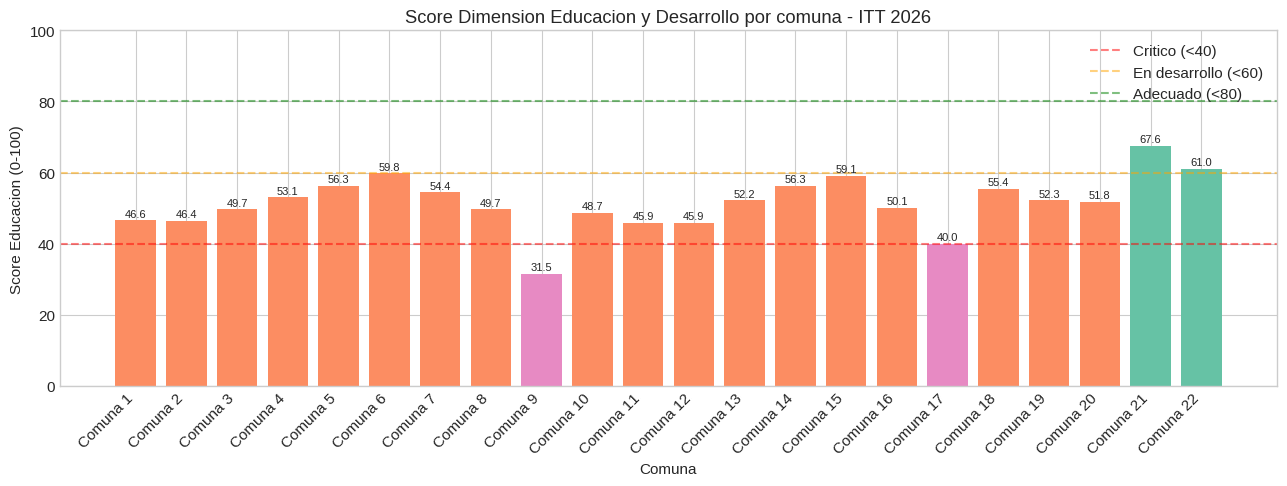

In [128]:
# Grafico 1: Score de dimension Educacion por comuna
fig, ax = plt.subplots(figsize=(13, 5))
colors = ['#e78ac3' if s < 40 else '#fc8d62' if s < 60 else '#66c2a5' if s < 80 else '#8da0cb'
          for s in df_edu['score_educacion']]
bars = ax.bar(df_edu['comuna'], df_edu['score_educacion'], color=colors)
ax.axhline(40, color='red', linestyle='--', alpha=0.5, label='Critico (<40)')
ax.axhline(60, color='orange', linestyle='--', alpha=0.5, label='En desarrollo (<60)')
ax.axhline(80, color='green', linestyle='--', alpha=0.5, label='Adecuado (<80)')
ax.set_xlabel('Comuna')
ax.set_ylabel('Score Educacion (0-100)')
ax.set_title('Score Dimension Educacion y Desarrollo por comuna - ITT 2026')
ax.set_ylim(0, 100)
ax.legend(loc='upper right')
plt.xticks(rotation=45, ha='right')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+1, f'{h:.1f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

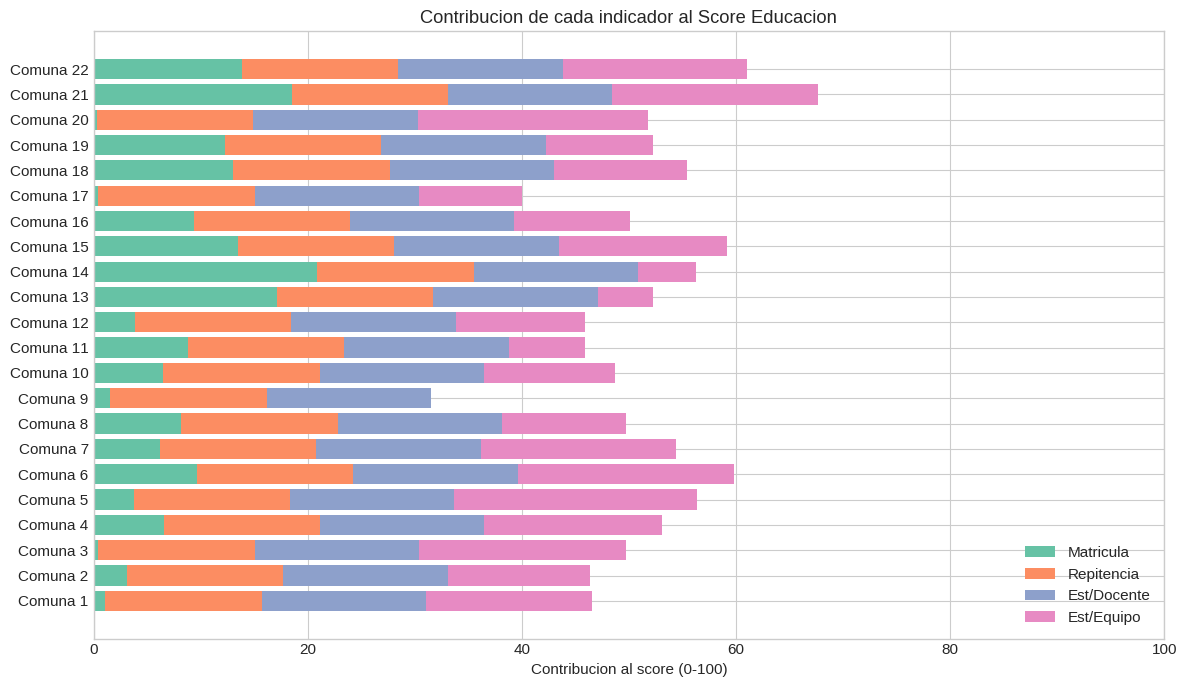

In [129]:
# Grafico 2: Desglose de scores por indicador (stacked horizontal)
fig, ax = plt.subplots(figsize=(12, 7))
comunas = df_edu['comuna']
y = range(len(comunas))

# Cada indicador contribuye 25% al score total
s1 = df_edu['score_matricula'] / 4
s2 = df_edu['score_repitencia'] / 4
s3 = df_edu['score_est_docente'] / 4
s4 = df_edu['score_est_equipo'] / 4

ax.barh(y, s1, label='Matricula', color='#66c2a5')
ax.barh(y, s2, left=s1, label='Repitencia', color='#fc8d62')
ax.barh(y, s3, left=s1+s2, label='Est/Docente', color='#8da0cb')
ax.barh(y, s4, left=s1+s2+s3, label='Est/Equipo', color='#e78ac3')

ax.set_yticks(y)
ax.set_yticklabels(comunas)
ax.set_xlabel('Contribucion al score (0-100)')
ax.set_title('Contribucion de cada indicador al Score Educacion')
ax.legend(loc='lower right')
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

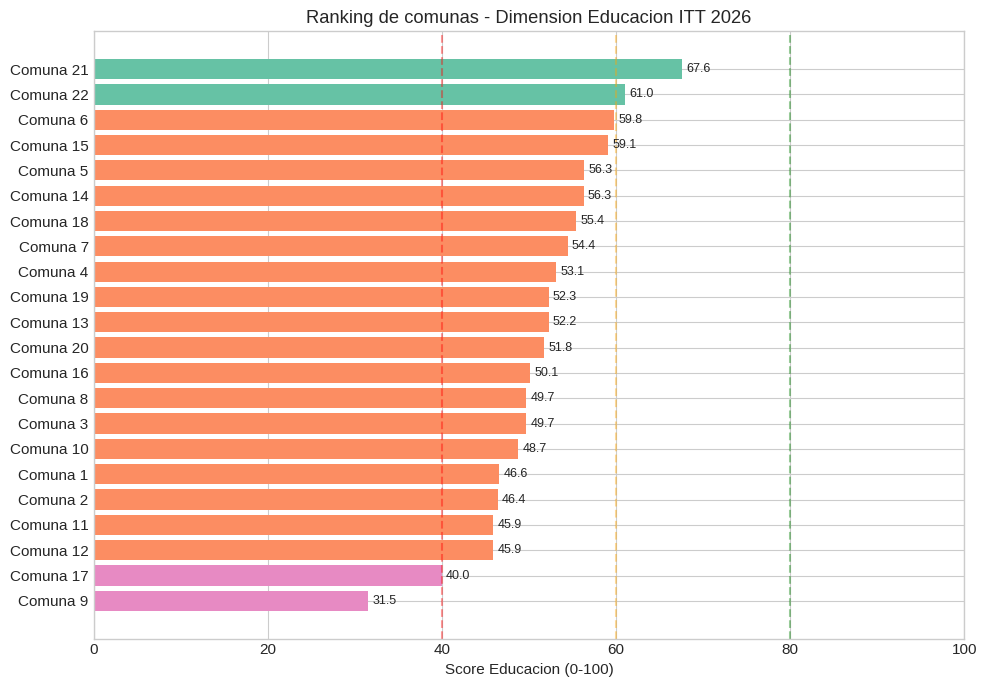

In [130]:
# Grafico 3: Ranking de comunas por score educacion
df_rank = df_edu[['comuna', 'score_educacion', 'nivel']].sort_values('score_educacion', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e78ac3' if s < 40 else '#fc8d62' if s < 60 else '#66c2a5' if s < 80 else '#8da0cb'
          for s in df_rank['score_educacion']]
bars = ax.barh(df_rank['comuna'], df_rank['score_educacion'], color=colors)
ax.axvline(40, color='red', linestyle='--', alpha=0.4)
ax.axvline(60, color='orange', linestyle='--', alpha=0.4)
ax.axvline(80, color='green', linestyle='--', alpha=0.4)
ax.set_xlabel('Score Educacion (0-100)')
ax.set_title('Ranking de comunas - Dimension Educacion ITT 2026')
ax.set_xlim(0, 100)
for bar in bars:
    w = bar.get_width()
    ax.text(w+0.5, bar.get_y()+bar.get_height()/2, f'{w:.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 6. Resumen y valor para el ITT

In [131]:
# Resumen estadistico
print('=' * 60)
print('RESUMEN - DIMENSION EDUCACION Y DESARROLLO (ITT 2026)')
print('=' * 60)
print(f'\nScore promedio municipal: {df_edu["score_educacion"].mean():.1f}')
print(f'Score mediana:            {df_edu["score_educacion"].median():.1f}')
print(f'Score minimo:             {df_edu["score_educacion"].min():.1f} ({df_edu.loc[df_edu["score_educacion"].idxmin(), "comuna"]})')
print(f'Score maximo:             {df_edu["score_educacion"].max():.1f} ({df_edu.loc[df_edu["score_educacion"].idxmax(), "comuna"]})')
print(f'\nDistribucion por nivel:')
print(df_edu['nivel'].value_counts().to_string())
print(f'\n--- Valor para el ITT ---')
print(f'Score Educacion y Desarrollo (promedio 22 comunas): {df_edu["score_educacion"].mean():.1f}')
print(f'Este valor reemplaza el referente provisional de Pulmon de Oriente (54.9)')
print(f'\nNota: Repitencia y Est/Docente son constantes municipales.')
print(f'La variacion entre comunas se explica por Matricula y Est/Equipo.')

RESUMEN - DIMENSION EDUCACION Y DESARROLLO (ITT 2026)

Score promedio municipal: 51.5
Score mediana:            52.0
Score minimo:             31.5 (Comuna 9)
Score maximo:             67.6 (Comuna 21)

Distribucion por nivel:
nivel
Nivel 2 - En desarrollo    18
Nivel 1 - Critico           2
Nivel 3 - Adecuado          2

--- Valor para el ITT ---
Score Educacion y Desarrollo (promedio 22 comunas): 51.5
Este valor reemplaza el referente provisional de Pulmon de Oriente (54.9)

Nota: Repitencia y Est/Docente son constantes municipales.
La variacion entre comunas se explica por Matricula y Est/Equipo.


In [132]:
# Tabla final exportable
print('\nTabla completa de scores por comuna:')
print('=' * 60)
cols_export = ['comuna', 'matricula_total', 'est_equipo_prom', 'repitencia',
               'est_por_docente', 'score_matricula', 'score_repitencia',
               'score_est_docente', 'score_est_equipo', 'score_educacion', 'nivel']
df_export = df_edu[cols_export].copy()
df_export['matricula_total'] = df_export['matricula_total'].apply(lambda x: f'{x:,.0f}')
df_export['est_equipo_prom'] = df_export['est_equipo_prom'].apply(lambda x: f'{x:.2f}')
df_export['score_educacion'] = df_export['score_educacion'].apply(lambda x: f'{x:.1f}')
print(df_export.to_string(index=False))


Tabla completa de scores por comuna:
   comuna matricula_total est_equipo_prom  repitencia  est_por_docente  score_matricula  score_repitencia  score_est_docente  score_est_equipo score_educacion                   nivel
 Comuna 1           6,087            8.19        6.82            24.64             4.35             58.43              61.44             62.13            46.6 Nivel 2 - En desarrollo
 Comuna 2           8,101            9.86        6.82            24.64            12.40             58.43              61.44             53.37            46.4 Nivel 2 - En desarrollo
 Comuna 3           5,435            5.33        6.82            24.64             1.74             58.43              61.44             77.19            49.7 Nivel 2 - En desarrollo
 Comuna 4          11,541            7.37        6.82            24.64            26.16             58.43              61.44             66.46            53.1 Nivel 2 - En desarrollo
 Comuna 5           8,740            2.81      

---
## 7. Notas metodologicas

### Indicadores usados y su estado:
| Indicador | Valor | Tipo | Fuente | Variacion por comuna |
|---|---|---|---|---|
| Matricula total | 5,313 - 25,902 | Positivo | 01_Matricula_2026 (Por comuna) | SI |
| Repitencia | 6.82% | Inverso | 02_Indicadores_2026 (municipal) | NO (constante) |
| Est/Docente | 24.64 | Inverso | 03_Estudiantes_2026 (municipal) | NO (constante) |
| Est/Equipo | Variable | Inverso | 03_Estudiantes_2026 (por sede) | SI |

### Limitaciones:
- Repitencia y Est/Docente son valores municipales aplicados a todas las comunas.
- La variacion real del score entre comunas depende solo de Matricula y Est/Equipo.
- Cuando se consiga desglose de repitencia y docentes por comuna, el score sera mas preciso.
- No se incluye desercion (dato no disponible en las fuentes actuales).
- No se incluye cobertura bruta/neta por comuna (requiere poblacion DANE por comuna).

### Refs utilizados:
| Indicador | ref_min | ref_max | Sustento |
|---|---|---|---|
| Matricula | 5,000 | 30,000 | Rango observado en 22 comunas (5,313 - 25,902) |
| Repitencia | 1.0% | 15.0% | Meta PD <5%, max historico ~12% |
| Est/Docente | 15 | 40 | Estandar MEN: 32 urbano, ideal <25 |
| Est/Equipo | 1 | 20 | Meta PD: 1 equipo cada 5 est (ratio 5) |

---
## 8. Mapa coropletico - Score Educacion por comuna

Visualizacion espacial del score de la dimension Educacion usando el poligono de comunas de Cali.

In [133]:
# Instalar geopandas y folium si no estan (Colab)
try:
    import geopandas as gpd
    import folium
    from folium import Choropleth, GeoJsonTooltip
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'geopandas', 'folium', '-q'])
    import geopandas as gpd
    import folium
    from folium import Choropleth, GeoJsonTooltip

import zipfile
print('geopandas y folium listos')

geopandas y folium listos


In [134]:
# Cargar poligonos de comunas
ruta_comunas_zip = os.path.join(DATA_PATH, 'info_geografica', 'Comunas.zip')

# Descomprimir si es necesario
carpeta_comunas = os.path.join(DATA_PATH, 'info_geografica', 'Comunas')
if not os.path.exists(carpeta_comunas):
    with zipfile.ZipFile(ruta_comunas_zip, 'r') as z:
        z.extractall(os.path.join(DATA_PATH, 'info_geografica'))
    print('Comunas.zip descomprimido')

# Buscar el shapefile o geojson dentro
archivos_comunas = []
for root, dirs, files in os.walk(carpeta_comunas):
    for f in files:
        if f.endswith(('.shp', '.geojson', '.json')):
            archivos_comunas.append(os.path.join(root, f))

if not archivos_comunas:
    # Buscar directamente en info_geografica
    for root, dirs, files in os.walk(os.path.join(DATA_PATH, 'info_geografica')):
        for f in files:
            if 'omuna' in f and f.endswith(('.shp', '.geojson', '.json')):
                archivos_comunas.append(os.path.join(root, f))

print(f'Archivos encontrados: {archivos_comunas}')
gdf_comunas = gpd.read_file(archivos_comunas[0])
print(f'Comunas cargadas: {len(gdf_comunas)}')
print(f'CRS: {gdf_comunas.crs}')
print(f'Columnas: {gdf_comunas.columns.tolist()}')
gdf_comunas.head()

Comunas.zip descomprimido
Archivos encontrados: ['data/Fuentes de datos/info_geografica/Comunas.geojson', 'data/Fuentes de datos/info_geografica/comunas_extracted/Comunas.geojson']
Comunas cargadas: 22
CRS: EPSG:4326
Columnas: ['comuna', 'shape_leng', 'shape_area', 'nombre', 'area', 'geometry']


,comuna,shape_leng,shape_area,nombre,area,geometry
0,6,1.27,"5,000,000.00",Comuna 6,"5,393,999.01","POLYGON ((-76.49138 3.50558, -76.49149 3.50486..."
1,4,1.14,"5,000,000.00",Comuna 4,"4,527,406.21","POLYGON ((-76.51791 3.45366, -76.51792 3.45366..."
2,5,8.44,"4,000,000.00",Comuna 5,"4,207,294.67","POLYGON ((-76.50162 3.46006, -76.50163 3.46005..."
3,7,1.25,"5,000,000.00",Comuna 7,"5,273,078.75","POLYGON ((-76.4745 3.46517, -76.4745 3.46515, ..."
4,8,1.22,"5,000,000.00",Comuna 8,"5,280,052.13","POLYGON ((-76.50888 3.45389, -76.50651 3.45353..."


In [135]:
# Identificar columna de numero de comuna y preparar merge
# Buscar columna que tenga numeros de comuna (1-22)
col_comuna = None
for col in gdf_comunas.columns:
    if col == 'geometry':
        continue
    try:
        vals = pd.to_numeric(gdf_comunas[col], errors='coerce').dropna()
        if vals.between(1, 22).all() and len(vals) >= 20:
            col_comuna = col
            break
    except:
        pass

# Si no se encontro automaticamente, intentar por nombre
if col_comuna is None:
    for col in gdf_comunas.columns:
        if 'comuna' in col.lower() or 'com' in col.lower():
            col_comuna = col
            break

print(f'Columna de comuna identificada: {col_comuna}')
gdf_comunas['num_comuna'] = pd.to_numeric(gdf_comunas[col_comuna], errors='coerce').astype('Int64')

# Filtrar solo comunas urbanas
gdf_urb = gdf_comunas[gdf_comunas['num_comuna'].between(1, 22)].copy()
print(f'Comunas urbanas en shapefile: {len(gdf_urb)}')

# Merge con scores de educacion
gdf_edu = gdf_urb.merge(df_edu[['num_comuna', 'score_educacion', 'score_matricula',
                                 'score_est_equipo', 'nivel', 'matricula_total',
                                 'est_equipo_prom']],
                        on='num_comuna', how='left')
print(f'Comunas con score asignado: {gdf_edu["score_educacion"].notna().sum()}')

# Reproyectar a WGS84 para folium
gdf_edu = gdf_edu.to_crs(epsg=4326)
print('Reproyectado a EPSG:4326')

Columna de comuna identificada: comuna
Comunas urbanas en shapefile: 22
Comunas con score asignado: 22
Reproyectado a EPSG:4326


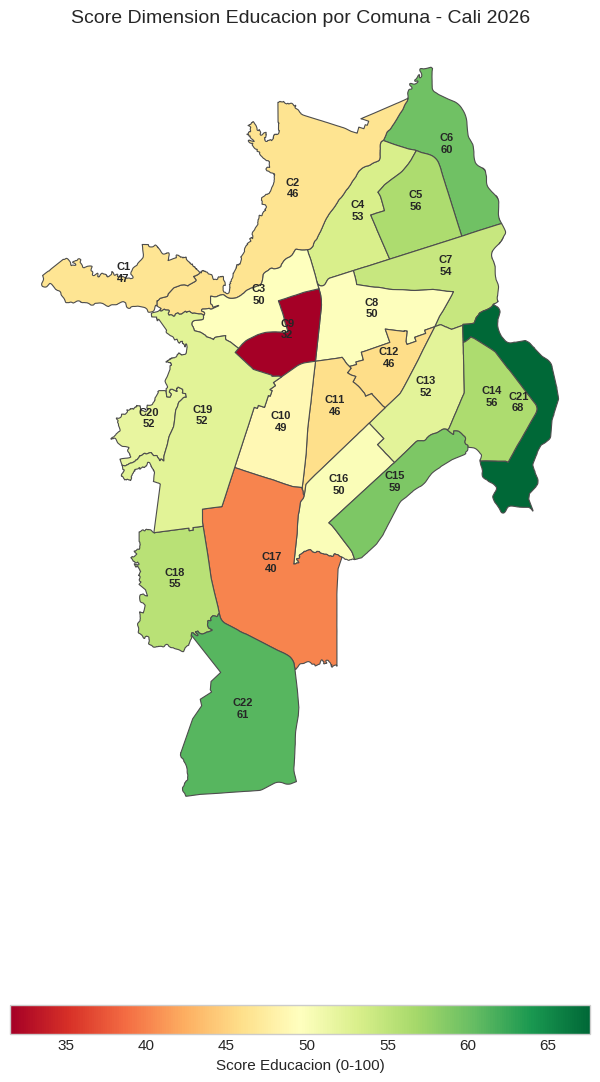

In [136]:
# Mapa coropletico con matplotlib (estatico)
fig, ax = plt.subplots(1, 1, figsize=(10, 12))
gdf_edu.plot(column='score_educacion', cmap='RdYlGn', linewidth=0.8,
             edgecolor='0.3', legend=True, ax=ax,
             legend_kwds={'label': 'Score Educacion (0-100)',
                          'orientation': 'horizontal',
                          'shrink': 0.6})

# Etiquetas de comuna
for idx, row in gdf_edu.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(f"C{int(row['num_comuna'])}\n{row['score_educacion']:.0f}",
                xy=(centroid.x, centroid.y), ha='center', fontsize=8,
                fontweight='bold')

ax.set_title('Score Dimension Educacion por Comuna - Cali 2026', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [137]:
# Mapa interactivo con Folium
# Centro de Cali
centro = [3.4516, -76.5320]
m = folium.Map(location=centro, zoom_start=12, tiles='CartoDB positron')

# Coropletico
folium.Choropleth(
    geo_data=gdf_edu.to_json(),
    data=df_edu,
    columns=['num_comuna', 'score_educacion'],
    key_on='feature.properties.num_comuna',
    fill_color='RdYlGn',
    fill_opacity=0.7,
    line_opacity=0.5,
    legend_name='Score Educacion (0-100)',
    nan_fill_color='gray'
).add_to(m)

# Tooltips con info
style_function = lambda x: {'fillColor': 'transparent', 'color': 'black', 'weight': 0.5}
folium.GeoJson(
    gdf_edu.to_json(),
    style_function=style_function,
    tooltip=folium.GeoJsonTooltip(
        fields=['num_comuna', 'score_educacion', 'matricula_total', 'est_equipo_prom', 'nivel'],
        aliases=['Comuna:', 'Score Educacion:', 'Matricula Total:', 'Est/Equipo:', 'Nivel:'],
        localize=True
    )
).add_to(m)

print('Mapa interactivo generado. Pasa el mouse sobre cada comuna para ver detalles.')
m

Mapa interactivo generado. Pasa el mouse sobre cada comuna para ver detalles.


---
## 9. Exportar GeoJSON con scores por comuna

Genera un archivo GeoJSON con los poligonos de comunas y todos los scores asociados,
listo para descargar y usar en QGIS, ArcGIS, Kepler.gl o cualquier visor geoespacial.

In [138]:
# Preparar GeoDataFrame para exportacion
cols_export = ['num_comuna', 'score_educacion', 'score_matricula',
               'score_est_equipo', 'nivel', 'matricula_total', 'est_equipo_prom',
               'geometry']

# Agregar columnas adicionales si existen
for col in ['score_repitencia', 'score_est_docente']:
    if col in gdf_edu.columns:
        cols_export.insert(-1, col)

gdf_export = gdf_edu[cols_export].copy()
gdf_export['num_comuna'] = gdf_export['num_comuna'].astype(int)
gdf_export['comuna_nombre'] = gdf_export['num_comuna'].apply(lambda x: f'Comuna {x}')

# Redondear scores
for col in gdf_export.select_dtypes(include=[np.number]).columns:
    if 'score' in col or 'equipo' in col:
        gdf_export[col] = gdf_export[col].round(2)

print(f'GeoDataFrame listo para exportar: {len(gdf_export)} comunas')
print(f'Columnas: {gdf_export.columns.tolist()}')
print(f'CRS: {gdf_export.crs}')
gdf_export.drop(columns='geometry').head()

GeoDataFrame listo para exportar: 22 comunas
Columnas: ['num_comuna', 'score_educacion', 'score_matricula', 'score_est_equipo', 'nivel', 'matricula_total', 'est_equipo_prom', 'geometry', 'comuna_nombre']
CRS: EPSG:4326


,num_comuna,score_educacion,score_matricula,score_est_equipo,nivel,matricula_total,est_equipo_prom,comuna_nombre
0,6,59.77,38.61,80.62,Nivel 2 - En desarrollo,14652,4.68,Comuna 6
1,4,53.12,26.16,66.46,Nivel 2 - En desarrollo,11541,7.37,Comuna 4
2,5,56.33,14.96,90.49,Nivel 2 - En desarrollo,8740,2.81,Comuna 5
3,7,54.44,24.74,73.15,Nivel 2 - En desarrollo,11184,6.10,Comuna 7
4,8,49.71,32.82,46.17,Nivel 2 - En desarrollo,13204,11.23,Comuna 8


In [139]:
# Exportar a GeoJSON
output_dir = 'outputs'
if IN_COLAB:
    output_dir = os.path.join(REPO_DIR, 'outputs')
else:
    output_dir = '../outputs'

os.makedirs(output_dir, exist_ok=True)
ruta_geojson = os.path.join(output_dir, 'score_educacion_por_comuna_2026.geojson')

gdf_export.to_file(ruta_geojson, driver='GeoJSON')
print(f'GeoJSON exportado: {ruta_geojson}')
print(f'Tamano: {os.path.getsize(ruta_geojson) / 1024:.1f} KB')

GeoJSON exportado: /content/Observatorio_de_Educacion/outputs/score_educacion_por_comuna_2026.geojson
Tamano: 1282.7 KB


In [140]:
# Descargar en Colab
if IN_COLAB:
    from google.colab import files
    files.download(ruta_geojson)
    print('Descarga iniciada...')
else:
    print(f'Archivo disponible en: {os.path.abspath(ruta_geojson)}')
    print('Para usarlo: abrir en QGIS, ArcGIS, kepler.gl o geojson.io')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descarga iniciada...


---
## 10. Linea base de Infraestructura Educativa (2020-2025)

Integramos el historico de obras para calcular la dimension Infraestructura del ICET
y generar graficos de evolucion temporal y heatmaps por comuna.

In [141]:
# Cargar historico de obras 2020-2025
ruta_obras = os.path.join(DATA_PATH, 'Intervenciones de infraestructura', 'HISTORICO OBRAS 2020-2025.xlsx')
df_obras_raw = pd.read_excel(ruta_obras, header=None, skiprows=2)
df_obras_raw.columns = ['Num', 'Ano', 'IEO', 'Sede', 'Com', 'Estudiantes', 'Comuna',
                         'Proyecto', 'Valor_obra', 'Valor_interventoria', 'Valor_estudios',
                         'Inversion', 'Contrato_obra', 'Contratista_obra',
                         'Contrato_interventoria', 'Contratista_interventoria',
                         'Contrato_estudios', 'Contratista_estudios', 'Actividad']

# Limpiar: filtrar filas validas
df_obras_raw['Ano'] = pd.to_numeric(df_obras_raw['Ano'], errors='coerce')
df_obras = df_obras_raw[df_obras_raw['Ano'].notna()].copy()
df_obras['Com_num'] = pd.to_numeric(df_obras['Com'], errors='coerce').astype('Int64')
df_obras['Estudiantes_num'] = pd.to_numeric(df_obras['Estudiantes'], errors='coerce')
df_obras['Inversion_num'] = pd.to_numeric(df_obras['Inversion'], errors='coerce')
df_obras['Ano'] = df_obras['Ano'].astype(int)

# Filtrar comunas urbanas
df_obras_urb = df_obras[df_obras['Com_num'].between(1, 22)].copy()

print(f'Registros totales: {len(df_obras)}')
print(f'Registros urbanos: {len(df_obras_urb)}')
print(f'Anos: {sorted(df_obras_urb["Ano"].unique())}')
print(f'Comunas: {df_obras_urb["Com_num"].nunique()}')
print(f'Sedes intervenidas: {df_obras_urb["Sede"].nunique()}')
print(f'Inversion total urbana: ${df_obras_urb["Inversion_num"].sum():,.0f}')

Registros totales: 475
Registros urbanos: 388
Anos: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Comunas: 21
Sedes intervenidas: 199
Inversion total urbana: $69,540,060,654


In [142]:
# Agregar por comuna y ano
agg_obras = df_obras_urb.groupby(['Com_num', 'Ano']).agg(
    obras=('Num', 'count'),
    inversion=('Inversion_num', 'sum'),
    estudiantes_beneficiados=('Estudiantes_num', 'sum'),
    sedes_intervenidas=('Sede', 'nunique')
).reset_index()

# Agregar solo por comuna (total historico)
agg_comuna = df_obras_urb.groupby('Com_num').agg(
    obras_total=('Num', 'count'),
    inversion_total=('Inversion_num', 'sum'),
    estudiantes_beneficiados=('Estudiantes_num', 'sum'),
    sedes_intervenidas=('Sede', 'nunique'),
    anos_con_obra=('Ano', 'nunique')
).reset_index()
agg_comuna.rename(columns={'Com_num': 'num_comuna'}, inplace=True)

print(f'Tabla por comuna-ano: {agg_obras.shape}')
print(f'Tabla por comuna (total): {agg_comuna.shape}')
print()
print('Resumen por comuna (historico 2020-2025):')
display_agg = agg_comuna.copy()
display_agg['inversion_total'] = display_agg['inversion_total'].apply(lambda x: f'${x:,.0f}')
display_agg['estudiantes_beneficiados'] = display_agg['estudiantes_beneficiados'].apply(lambda x: f'{x:,.0f}')
print(display_agg.to_string(index=False))

Tabla por comuna-ano: (94, 6)
Tabla por comuna (total): (21, 6)

Resumen por comuna (historico 2020-2025):
 num_comuna  obras_total inversion_total estudiantes_beneficiados  sedes_intervenidas  anos_con_obra
          1           16  $1,100,853,534                    6,246                   8              4
          2           13  $5,790,544,531                    5,576                   5              5
          3           29  $7,532,875,499                   17,767                   9              5
          4           25  $3,940,211,837                   13,616                  14              5
          5            9  $1,431,086,450                    8,800                   4              5
          6            7  $1,991,797,813                    5,450                   3              4
          7           17  $2,582,938,964                    7,163                  11              4
          8           33  $5,457,899,620                   12,433                  21

### 10.1 Heatmap: Obras por comuna y ano

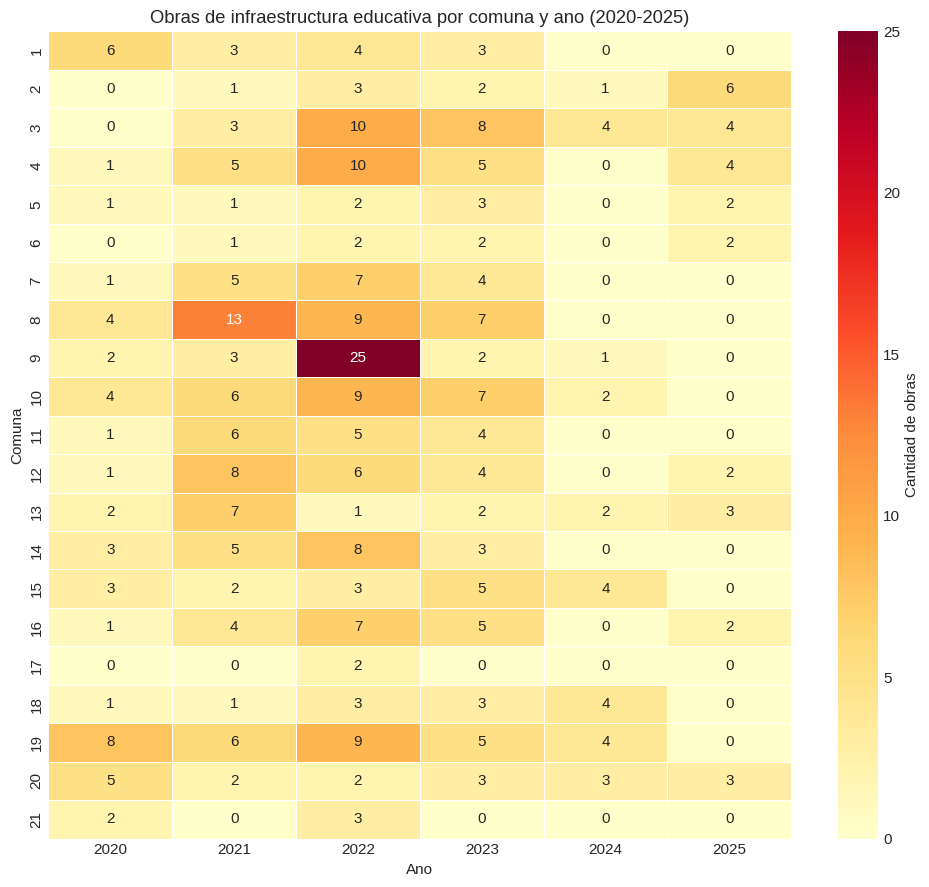

In [143]:
# Pivot para heatmap
pivot_obras = agg_obras.pivot_table(index='Com_num', columns='Ano',
                                     values='obras', fill_value=0)

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(pivot_obras, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Cantidad de obras'})
ax.set_xlabel('Ano')
ax.set_ylabel('Comuna')
ax.set_title('Obras de infraestructura educativa por comuna y ano (2020-2025)')
plt.tight_layout()
plt.show()

### 10.2 Heatmap: Inversion por comuna y ano

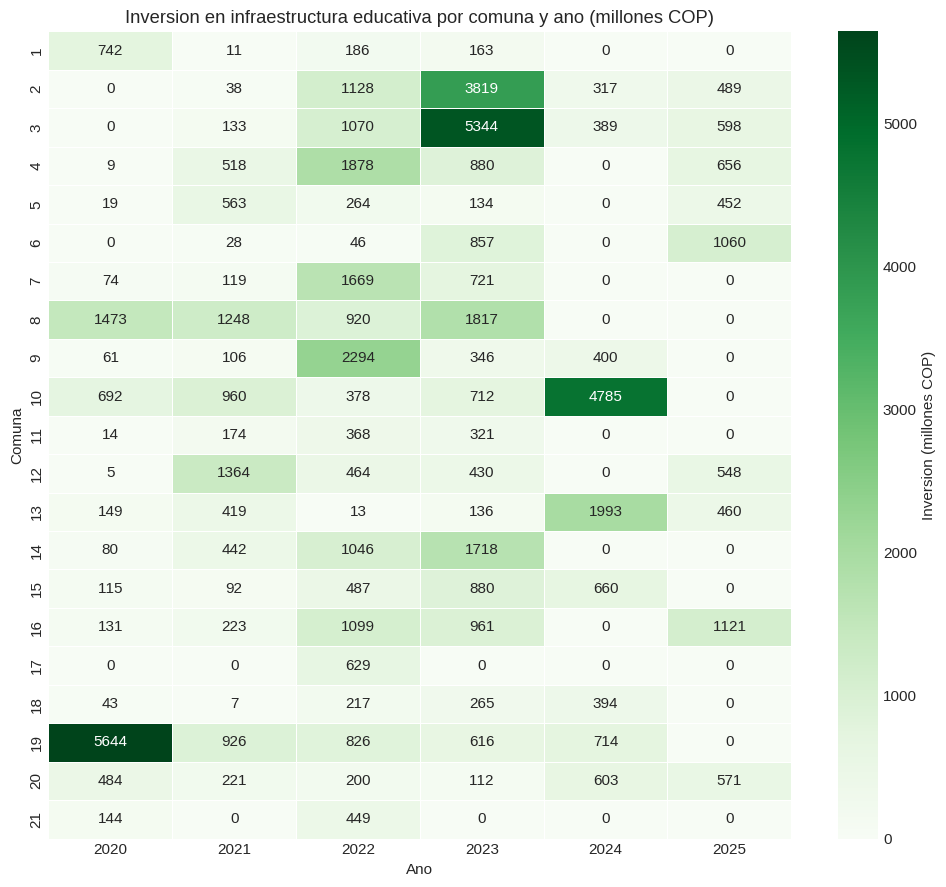

In [144]:
# Pivot inversion (en millones)
pivot_inv = agg_obras.pivot_table(index='Com_num', columns='Ano',
                                   values='inversion', fill_value=0) / 1_000_000

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(pivot_inv, annot=True, fmt='.0f', cmap='Greens',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Inversion (millones COP)'})
ax.set_xlabel('Ano')
ax.set_ylabel('Comuna')
ax.set_title('Inversion en infraestructura educativa por comuna y ano (millones COP)')
plt.tight_layout()
plt.show()

### 10.3 Evolucion temporal de la inversion

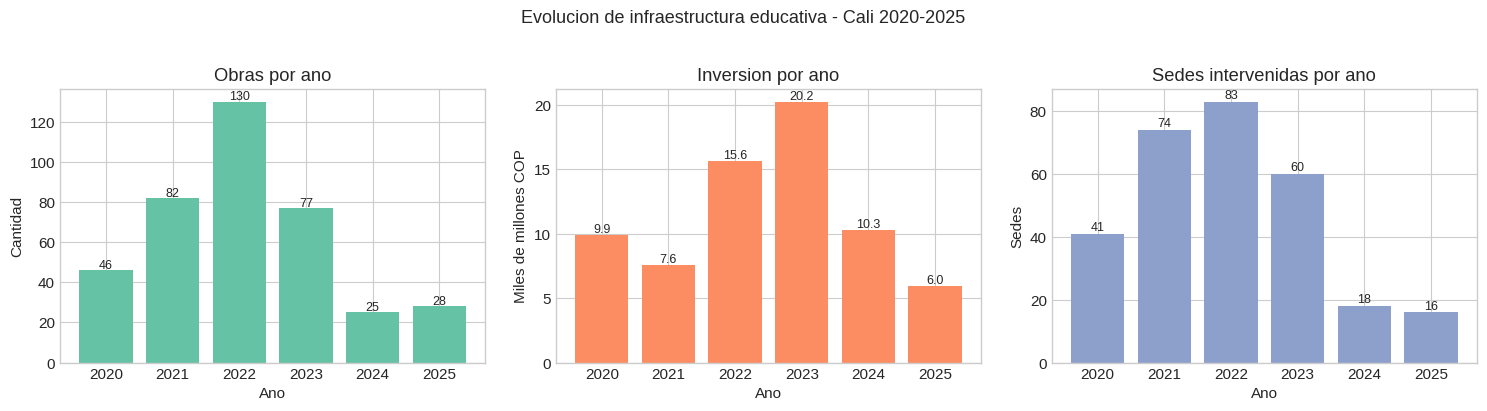

In [145]:
# Evolucion anual total
evol = df_obras_urb.groupby('Ano').agg(
    obras=('Num', 'count'),
    inversion=('Inversion_num', 'sum'),
    sedes=('Sede', 'nunique'),
    comunas=('Com_num', 'nunique')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Obras por ano
axes[0].bar(evol['Ano'], evol['obras'], color='#66c2a5')
axes[0].set_title('Obras por ano')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(evol['obras']):
    axes[0].text(evol['Ano'].iloc[i], v+1, str(v), ha='center', fontsize=9)

# Inversion por ano
axes[1].bar(evol['Ano'], evol['inversion']/1e9, color='#fc8d62')
axes[1].set_title('Inversion por ano')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Miles de millones COP')
for i, v in enumerate(evol['inversion']/1e9):
    axes[1].text(evol['Ano'].iloc[i], v+0.2, f'{v:.1f}', ha='center', fontsize=9)

# Sedes por ano
axes[2].bar(evol['Ano'], evol['sedes'], color='#8da0cb')
axes[2].set_title('Sedes intervenidas por ano')
axes[2].set_xlabel('Ano')
axes[2].set_ylabel('Sedes')
for i, v in enumerate(evol['sedes']):
    axes[2].text(evol['Ano'].iloc[i], v+1, str(v), ha='center', fontsize=9)

plt.suptitle('Evolucion de infraestructura educativa - Cali 2020-2025', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 10.4 Ranking de comunas por inversion acumulada

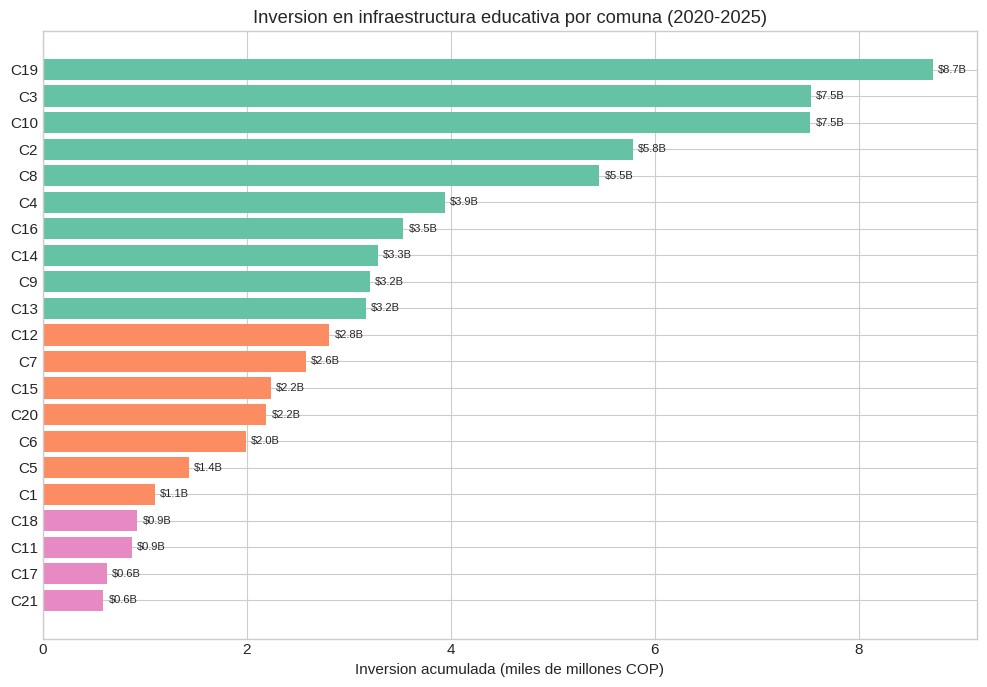

In [146]:
# Ranking inversion
rank = agg_comuna.sort_values('inversion_total', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e78ac3' if v < 1e9 else '#fc8d62' if v < 3e9 else '#66c2a5'
          for v in rank['inversion_total']]
bars = ax.barh([f'C{int(c)}' for c in rank['num_comuna']],
              rank['inversion_total']/1e9, color=colors)
ax.set_xlabel('Inversion acumulada (miles de millones COP)')
ax.set_title('Inversion en infraestructura educativa por comuna (2020-2025)')
for bar in bars:
    w = bar.get_width()
    ax.text(w+0.05, bar.get_y()+bar.get_height()/2,
            f'${w:.1f}B', va='center', fontsize=8)
plt.tight_layout()
plt.show()

### 10.5 Score de Infraestructura por comuna

In [147]:
# Definir refs para infraestructura
# Indicadores: obras_total y inversion_total
REFS_INFRA = {
    'obras_total': (1, 35, False, 'Obras acumuladas 2020-2025 (mas = mejor)'),
    'inversion_total_M': (100, 9000, False, 'Inversion acumulada en millones (mas = mejor)'),
}

# Calcular scores de infraestructura
agg_comuna['inversion_M'] = agg_comuna['inversion_total'] / 1_000_000

agg_comuna['score_obras'] = agg_comuna['obras_total'].apply(
    lambda v: score_ref(v, 1, 35, False))
agg_comuna['score_inversion'] = agg_comuna['inversion_M'].apply(
    lambda v: score_ref(v, 100, 9000, False))

agg_comuna['score_infraestructura'] = (
    agg_comuna['score_obras'] + agg_comuna['score_inversion']
) / 2

print('Score Infraestructura por comuna:')
print(agg_comuna[['num_comuna', 'obras_total', 'inversion_M',
                   'score_obras', 'score_inversion', 'score_infraestructura'
                  ]].sort_values('num_comuna').to_string(index=False))

Score Infraestructura por comuna:
 num_comuna  obras_total  inversion_M  score_obras  score_inversion  score_infraestructura
          1           16     1,100.85        44.12            11.25                  27.68
          2           13     5,790.54        35.29            63.94                  49.62
          3           29     7,532.88        82.35            83.52                  82.93
          4           25     3,940.21        70.59            43.15                  56.87
          5            9     1,431.09        23.53            14.96                  19.24
          6            7     1,991.80        17.65            21.26                  19.45
          7           17     2,582.94        47.06            27.90                  37.48
          8           33     5,457.90        94.12            60.20                  77.16
          9           33     3,206.75        94.12            34.91                  64.51
         10           28     7,526.78        79.41      

### 10.6 ICET actualizado: Educacion + Infraestructura

In [148]:
# Merge infraestructura con educacion
df_icet = df_edu.merge(
    agg_comuna[['num_comuna', 'obras_total', 'inversion_M',
                'score_obras', 'score_inversion', 'score_infraestructura']],
    on='num_comuna', how='left'
)

# ICET con 4 dimensiones (reponderado)
# Original: Cobertura 30%, Eficiencia 25%, Recursos 20%, Infraestructura 15%, Dotacion 10%
# Disponible: Educacion (agrupa Cobertura+Eficiencia+Recursos+Dotacion) + Infraestructura
# Pesos reponderados: Educacion 85% -> 100% sin infra, con infra: Educacion 75%, Infra 25%
PESO_EDUCACION = 0.75
PESO_INFRA = 0.25

df_icet['icet_parcial'] = (
    PESO_EDUCACION * df_icet['score_educacion'] +
    PESO_INFRA * df_icet['score_infraestructura']
)

df_icet['nivel_icet'] = df_icet['icet_parcial'].apply(clasificar)

print('ICET parcial (Educacion 75% + Infraestructura 25%):')
print(f'  Promedio: {df_icet["icet_parcial"].mean():.1f}')
print(f'  Min: {df_icet["icet_parcial"].min():.1f} ({df_icet.loc[df_icet["icet_parcial"].idxmin(), "comuna"]})')
print(f'  Max: {df_icet["icet_parcial"].max():.1f} ({df_icet.loc[df_icet["icet_parcial"].idxmax(), "comuna"]})')
print()
cols_show = ['comuna', 'score_educacion', 'score_infraestructura', 'icet_parcial', 'nivel_icet']
print(df_icet[cols_show].sort_values('icet_parcial', ascending=False).to_string(index=False))

ICET parcial (Educacion 75% + Infraestructura 25%):
  Promedio: 49.3
  Min: 31.1 (Comuna 17)
  Max: 62.7 (Comuna 19)

   comuna  score_educacion  score_infraestructura  icet_parcial              nivel_icet
Comuna 19            52.26                  94.05         62.71      Nivel 3 - Adecuado
 Comuna 3            49.70                  82.93         58.01 Nivel 2 - En desarrollo
Comuna 10            48.73                  81.43         56.90 Nivel 2 - En desarrollo
 Comuna 8            49.71                  77.16         56.58 Nivel 2 - En desarrollo
 Comuna 4            53.12                  56.87         54.06 Nivel 2 - En desarrollo
Comuna 14            56.28                  44.37         53.30 Nivel 2 - En desarrollo
Comuna 15            59.12                  35.52         53.22 Nivel 2 - En desarrollo
Comuna 21            67.61                   8.65         52.87 Nivel 2 - En desarrollo
 Comuna 7            54.44                  37.48         50.20 Nivel 2 - En desarrollo
 C

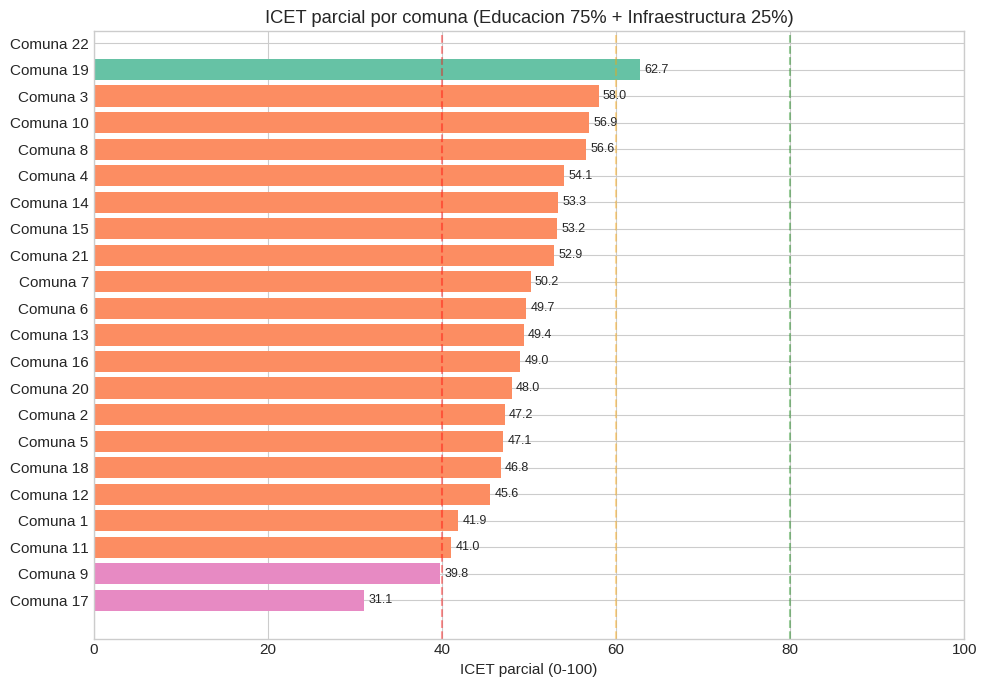

In [149]:
# Grafico: ICET parcial por comuna
df_plot = df_icet.sort_values('icet_parcial', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e78ac3' if s < 40 else '#fc8d62' if s < 60 else '#66c2a5' if s < 80 else '#8da0cb'
          for s in df_plot['icet_parcial']]
bars = ax.barh(df_plot['comuna'], df_plot['icet_parcial'], color=colors)
ax.axvline(40, color='red', linestyle='--', alpha=0.4)
ax.axvline(60, color='orange', linestyle='--', alpha=0.4)
ax.axvline(80, color='green', linestyle='--', alpha=0.4)
ax.set_xlabel('ICET parcial (0-100)')
ax.set_title('ICET parcial por comuna (Educacion 75% + Infraestructura 25%)')
ax.set_xlim(0, 100)
for bar in bars:
    w = bar.get_width()
    ax.text(w+0.5, bar.get_y()+bar.get_height()/2, f'{w:.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

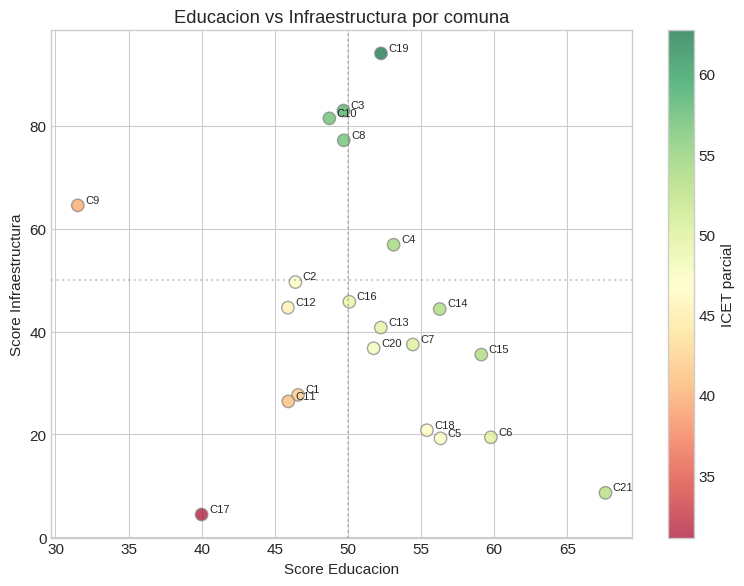

In [150]:
# Scatter: Score Educacion vs Score Infraestructura
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df_icet['score_educacion'], df_icet['score_infraestructura'],
           s=80, alpha=0.7, c=df_icet['icet_parcial'], cmap='RdYlGn', edgecolors='gray')
for _, row in df_icet.iterrows():
    ax.annotate(f"C{int(row['num_comuna'])}",
                (row['score_educacion']+0.5, row['score_infraestructura']+0.5), fontsize=8)
ax.set_xlabel('Score Educacion')
ax.set_ylabel('Score Infraestructura')
ax.set_title('Educacion vs Infraestructura por comuna')
ax.axhline(50, color='gray', linestyle=':', alpha=0.4)
ax.axvline(50, color='gray', linestyle=':', alpha=0.4)
plt.colorbar(ax.collections[0], ax=ax, label='ICET parcial')
plt.tight_layout()
plt.show()

---
## 11. Instituciones Educativas (IE) por comuna

Contamos las IE y sedes por comuna para contextualizar los indices.
Una comuna con mas IE y sedes tiene mayor oferta educativa, lo que
debe considerarse al interpretar los scores.

In [151]:
# Contar IE y sedes por comuna desde info geografica
df_geo_full = pd.read_excel(ruta_geo) if 'df_geo' not in dir() else df_geo.copy()

# Usar el df_geo ya cargado
df_geo_ie = df_geo[['EeCodDane', 'EeNomIns', 'EeConSede', 'EEComCor']].copy()
df_geo_ie['EEComCor'] = pd.to_numeric(df_geo_ie['EEComCor'], errors='coerce')
df_geo_ie = df_geo_ie[df_geo_ie['EEComCor'].between(1, 22)].copy()
df_geo_ie['num_comuna'] = df_geo_ie['EEComCor'].astype(int)

# Contar IE unicas y sedes por comuna
ie_comuna = df_geo_ie.groupby('num_comuna').agg(
    instituciones=('EeNomIns', 'nunique'),
    sedes_total=('EeCodDane', 'nunique')
).reset_index()

ie_comuna['sedes_por_ie'] = (ie_comuna['sedes_total'] / ie_comuna['instituciones']).round(1)

print(f'IE y sedes por comuna (info geografica):')
print(ie_comuna.sort_values('num_comuna').to_string(index=False))
print(f'\nTotal IE urbanas: {ie_comuna["instituciones"].sum()}')
print(f'Total sedes urbanas: {ie_comuna["sedes_total"].sum()}')

IE y sedes por comuna (info geografica):
 num_comuna  instituciones  sedes_total  sedes_por_ie
          1              4            4          1.00
          2              1            1          1.00
          3              2            2          1.00
          4              8            8          1.00
          5              2            2          1.00
          6              3            3          1.00
          7              6            6          1.00
          8              7            7          1.00
          9              3            3          1.00
         10              6            6          1.00
         11              7            7          1.00
         12              5            5          1.00
         13              7            7          1.00
         14              5            5          1.00
         15              6            6          1.00
         16              5            5          1.00
         17              1            1  

In [152]:
# Merge con tabla ICET
df_icet = df_icet.merge(ie_comuna, on='num_comuna', how='left')

# Calcular indicadores per capita (por IE)
df_icet['matricula_por_ie'] = (df_icet['matricula_total'] / df_icet['instituciones']).round(0)
df_icet['equipos_por_ie'] = (df_icet['equipos_total'] / df_icet['instituciones']).round(0)
df_icet['obras_por_ie'] = (df_icet['obras_total'] / df_icet['instituciones']).round(2)

print('Tabla ICET con IE por comuna:')
cols = ['comuna', 'instituciones', 'sedes_total', 'matricula_total',
        'matricula_por_ie', 'equipos_por_ie', 'obras_por_ie', 'icet_parcial']
print(df_icet[cols].sort_values('comuna').to_string(index=False))

Tabla ICET con IE por comuna:
   comuna  instituciones  sedes_total  matricula_total  matricula_por_ie  equipos_por_ie  obras_por_ie  icet_parcial
 Comuna 1              4            4             6087          1,522.00          215.00          4.00         41.86
Comuna 10              6            6            11520          1,920.00          325.00          4.67         56.90
Comuna 11              7            7            13788          1,970.00          480.00          2.29         41.05
Comuna 12              5            5             8846          1,769.00          271.00          4.20         45.58
Comuna 13              7            7            22107          3,158.00          211.00          2.43         49.38
Comuna 14              5            5            25902          5,180.00          495.00          3.80         53.30
Comuna 15              6            6            18479          3,080.00          492.00          2.83         53.22
Comuna 16              5          

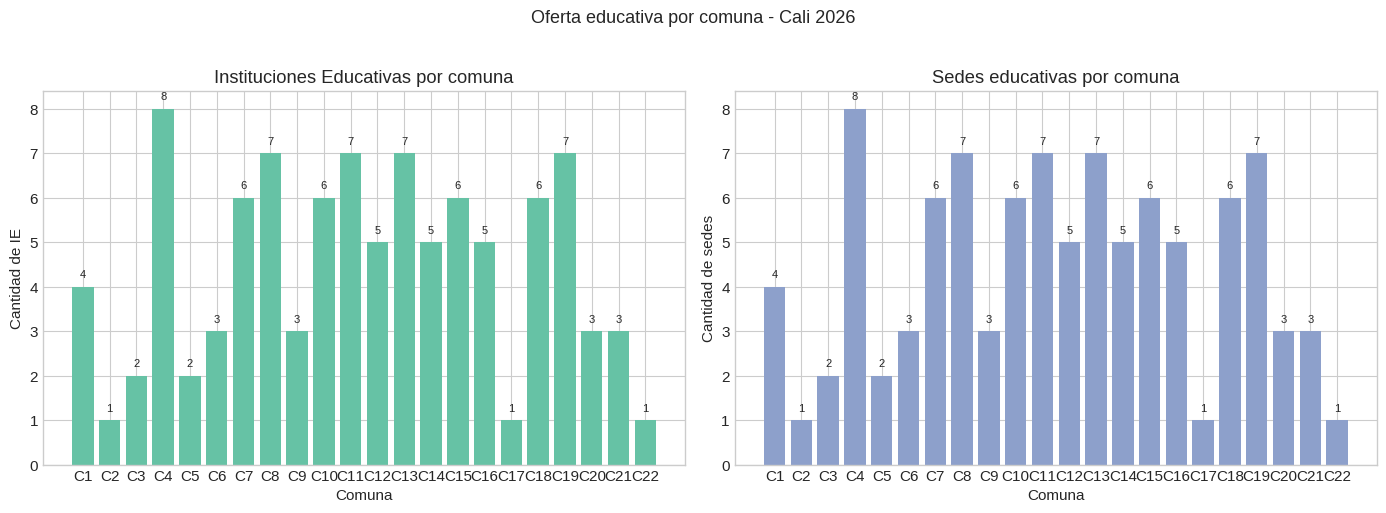

In [153]:
# Grafico: IE y sedes por comuna
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comunas_label = [f'C{i}' for i in df_icet.sort_values('num_comuna')['num_comuna']]
df_sorted = df_icet.sort_values('num_comuna')

# IE por comuna
bars = axes[0].bar(comunas_label, df_sorted['instituciones'], color='#66c2a5')
axes[0].set_title('Instituciones Educativas por comuna')
axes[0].set_xlabel('Comuna')
axes[0].set_ylabel('Cantidad de IE')
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x()+bar.get_width()/2, h+0.2, f'{int(h)}', ha='center', fontsize=8)

# Sedes por comuna
bars = axes[1].bar(comunas_label, df_sorted['sedes_total'], color='#8da0cb')
axes[1].set_title('Sedes educativas por comuna')
axes[1].set_xlabel('Comuna')
axes[1].set_ylabel('Cantidad de sedes')
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x()+bar.get_width()/2, h+0.2, f'{int(h)}', ha='center', fontsize=8)

plt.suptitle('Oferta educativa por comuna - Cali 2026', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

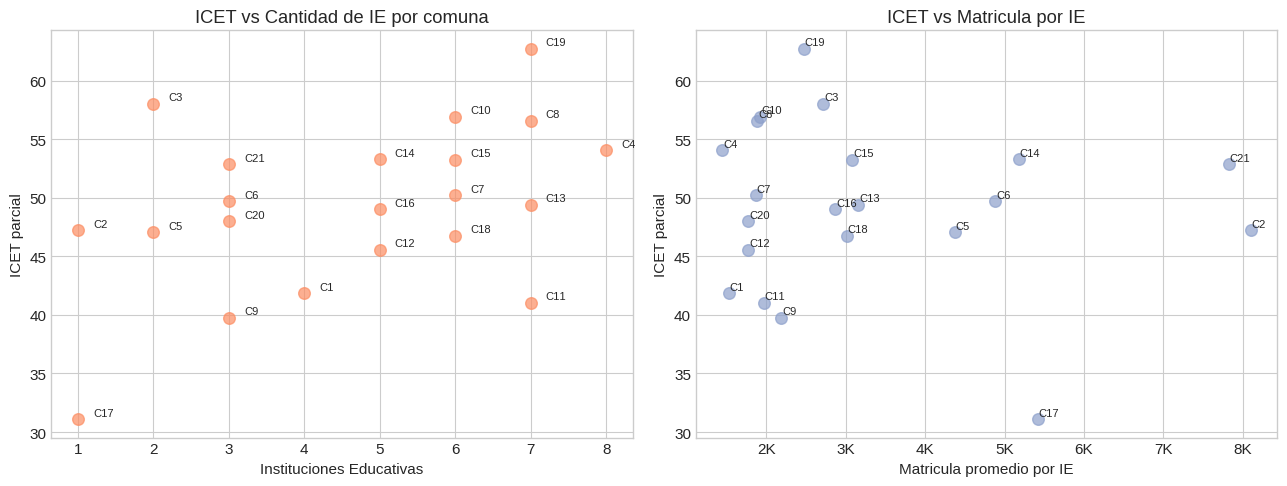

In [154]:
# Grafico: ICET vs cantidad de IE (contexto)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ICET vs IE
axes[0].scatter(df_icet['instituciones'], df_icet['icet_parcial'],
               s=70, alpha=0.7, color='#fc8d62')
for _, row in df_icet.iterrows():
    axes[0].annotate(f"C{int(row['num_comuna'])}",
                     (row['instituciones']+0.2, row['icet_parcial']+0.3), fontsize=8)
axes[0].set_xlabel('Instituciones Educativas')
axes[0].set_ylabel('ICET parcial')
axes[0].set_title('ICET vs Cantidad de IE por comuna')

# Matricula por IE vs ICET
axes[1].scatter(df_icet['matricula_por_ie'], df_icet['icet_parcial'],
               s=70, alpha=0.7, color='#8da0cb')
for _, row in df_icet.iterrows():
    axes[1].annotate(f"C{int(row['num_comuna'])}",
                     (row['matricula_por_ie']+10, row['icet_parcial']+0.3), fontsize=8)
axes[1].set_xlabel('Matricula promedio por IE')
axes[1].set_ylabel('ICET parcial')
axes[1].set_title('ICET vs Matricula por IE')
fmt_eje(axes[1], 'x')

plt.tight_layout()
plt.show()

In [155]:
# Resumen: tabla final con todos los indicadores
print('=' * 70)
print('TABLA FINAL - ICET CON CONTEXTO DE IE POR COMUNA')
print('=' * 70)
cols_final = ['comuna', 'instituciones', 'sedes_total', 'matricula_total',
              'est_equipo_prom', 'obras_total', 'inversion_M',
              'score_educacion', 'score_infraestructura', 'icet_parcial', 'nivel_icet']
df_show = df_icet[cols_final].sort_values('icet_parcial', ascending=False).copy()
df_show['matricula_total'] = df_show['matricula_total'].apply(lambda x: f'{x:,.0f}')
df_show['inversion_M'] = df_show['inversion_M'].apply(lambda x: f'${x:,.0f}M')
df_show['est_equipo_prom'] = df_show['est_equipo_prom'].apply(lambda x: f'{x:.1f}')
df_show['score_educacion'] = df_show['score_educacion'].apply(lambda x: f'{x:.1f}')
df_show['score_infraestructura'] = df_show['score_infraestructura'].apply(lambda x: f'{x:.1f}')
df_show['icet_parcial'] = df_show['icet_parcial'].apply(lambda x: f'{x:.1f}')
print(df_show.to_string(index=False))

TABLA FINAL - ICET CON CONTEXTO DE IE POR COMUNA
   comuna  instituciones  sedes_total matricula_total est_equipo_prom  obras_total inversion_M score_educacion score_infraestructura icet_parcial              nivel_icet
Comuna 19              7            7          17,274            12.4        32.00     $8,726M            52.3                  94.0         62.7      Nivel 3 - Adecuado
 Comuna 3              2            2           5,435             5.3        29.00     $7,533M            49.7                  82.9         58.0 Nivel 2 - En desarrollo
Comuna 10              6            6          11,520            10.7        28.00     $7,527M            48.7                  81.4         56.9 Nivel 2 - En desarrollo
 Comuna 8              7            7          13,204            11.2        33.00     $5,458M            49.7                  77.2         56.6 Nivel 2 - En desarrollo
 Comuna 4              8            8          11,541             7.4        25.00     $3,940M       

---
## 12. Comparacion Historico (2020-2025) vs 2026 T1

Cruzamos la linea base historica de infraestructura con los datos actuales 2026
para identificar brechas, evaluar impacto de la inversion y priorizar comunas.

In [156]:
# Construir tabla comparativa por comuna
# Historico: obras, inversion, estudiantes en sedes intervenidas
# 2026: matricula, equipos, est/equipo, sedes

df_comp = df_icet[['num_comuna', 'comuna', 'matricula_total', 'sedes_total',
                    'equipos_total', 'est_equipo_prom', 'obras_total',
                    'inversion_M', 'score_educacion', 'score_infraestructura',
                    'icet_parcial']].copy()

# Calcular % de sedes intervenidas
df_comp['sedes_intervenidas'] = agg_comuna.set_index('num_comuna')['sedes_intervenidas'].reindex(df_comp['num_comuna'].values).values
df_comp['pct_sedes_intervenidas'] = (df_comp['sedes_intervenidas'] / df_comp['sedes_total'] * 100).round(1)

# Inversion per capita (por estudiante)
df_comp['inversion_por_estudiante'] = (df_comp['inversion_M'] * 1_000_000 / df_comp['matricula_total']).round(0)

print('Tabla comparativa Historico vs 2026:')
cols = ['comuna', 'matricula_total', 'sedes_total', 'sedes_intervenidas',
        'pct_sedes_intervenidas', 'obras_total', 'inversion_M',
        'inversion_por_estudiante', 'est_equipo_prom']
df_show = df_comp[cols].copy()
df_show['matricula_total'] = df_show['matricula_total'].apply(lambda x: f'{x:,.0f}')
df_show['inversion_M'] = df_show['inversion_M'].apply(lambda x: f'${x:,.0f}M')
df_show['inversion_por_estudiante'] = df_show['inversion_por_estudiante'].apply(lambda x: f'${x:,.0f}')
print(df_show.to_string(index=False))

Tabla comparativa Historico vs 2026:
   comuna matricula_total  sedes_total  sedes_intervenidas  pct_sedes_intervenidas  obras_total inversion_M inversion_por_estudiante  est_equipo_prom
 Comuna 1           6,087            4                8.00                  200.00        16.00     $1,101M                 $180,853             8.19
 Comuna 2           8,101            1                5.00                  500.00        13.00     $5,791M                 $714,794             9.86
 Comuna 3           5,435            2                9.00                  450.00        29.00     $7,533M               $1,385,994             5.33
 Comuna 4          11,541            8               14.00                  175.00        25.00     $3,940M                 $341,410             7.37
 Comuna 5           8,740            2                4.00                  200.00         9.00     $1,431M                 $163,740             2.81
 Comuna 6          14,652            3                3.00     

### 12.0 Linea base por comuna y ano (2020-2025)

In [ ]:
# Tabla: obras por comuna y ano
pivot_obras_comuna = df_obras_urb.groupby(['Com_num', 'Ano']).agg(
    obras=('Num', 'count'),
    inversion=('Inversion_num', 'sum'),
    estudiantes=('Estudiantes_num', 'sum')
).reset_index()

# Pivot: obras por comuna x ano
tabla_obras = pivot_obras_comuna.pivot_table(
    index='Com_num', columns='Ano', values='obras', fill_value=0, aggfunc='sum')
tabla_obras['Total'] = tabla_obras.sum(axis=1)
tabla_obras.index = [f'Comuna {int(c)}' for c in tabla_obras.index]

print('OBRAS POR COMUNA Y ANO (2020-2025)')
print('=' * 60)
print(tabla_obras.to_string())
print(f'\nTotal general: {tabla_obras["Total"].sum()} obras')

In [ ]:
# Tabla: inversion por comuna y ano (millones COP)
tabla_inv = pivot_obras_comuna.pivot_table(
    index='Com_num', columns='Ano', values='inversion', fill_value=0, aggfunc='sum') / 1_000_000
tabla_inv['Total_M'] = tabla_inv.sum(axis=1)
tabla_inv.index = [f'Comuna {int(c)}' for c in tabla_inv.index]

print('INVERSION POR COMUNA Y ANO (millones COP)')
print('=' * 60)
# Formatear con separador de miles
print(tabla_inv.applymap(lambda x: f'{x:,.0f}').to_string())
print(f'\nInversion total: ${tabla_inv["Total_M"].sum():,.0f} millones')

In [ ]:
# Tabla: estudiantes beneficiados por comuna y ano
tabla_est = pivot_obras_comuna.pivot_table(
    index='Com_num', columns='Ano', values='estudiantes', fill_value=0, aggfunc='sum')
tabla_est['Total'] = tabla_est.sum(axis=1)
tabla_est.index = [f'Comuna {int(c)}' for c in tabla_est.index]

print('ESTUDIANTES BENEFICIADOS POR COMUNA Y ANO (2020-2025)')
print('=' * 60)
print(tabla_est.applymap(lambda x: f'{x:,.0f}').to_string())
print(f'\nTotal estudiantes beneficiados: {tabla_est["Total"].sum():,.0f}')

In [ ]:
# Grafico: Heatmap obras por comuna y ano
pivot_hm = df_obras_urb.groupby(['Com_num', 'Ano']).size().reset_index(name='obras')
pivot_hm = pivot_hm.pivot(index='Com_num', columns='Ano', values='obras').fillna(0)
pivot_hm.index = [f'C{int(c)}' for c in pivot_hm.index]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot_hm, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Obras'})
ax.set_xlabel('Ano')
ax.set_ylabel('Comuna')
ax.set_title('Obras de infraestructura educativa por comuna y ano')
plt.tight_layout()
plt.show()

In [ ]:
# Grafico: Heatmap inversion por comuna y ano
pivot_inv_hm = pivot_obras_comuna.pivot_table(
    index='Com_num', columns='Ano', values='inversion', fill_value=0, aggfunc='sum') / 1_000_000
pivot_inv_hm.index = [f'C{int(c)}' for c in pivot_inv_hm.index]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot_inv_hm, annot=True, fmt='.0f', cmap='Greens',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Millones COP'})
ax.set_xlabel('Ano')
ax.set_ylabel('Comuna')
ax.set_title('Inversion en infraestructura educativa por comuna y ano (millones COP)')
plt.tight_layout()
plt.show()

In [ ]:
# Grafico: Barras apiladas - obras por ano coloreadas por comuna (top 8)
top8 = tabla_obras.nlargest(8, 'Total').index.tolist()
top8_nums = [int(c.replace('Comuna ', '')) for c in top8]

df_top = df_obras_urb[df_obras_urb['Com_num'].isin(top8_nums)].copy()
pivot_top = df_top.groupby(['Ano', 'Com_num']).size().reset_index(name='obras')
pivot_top = pivot_top.pivot(index='Ano', columns='Com_num', values='obras').fillna(0)
pivot_top.columns = [f'C{int(c)}' for c in pivot_top.columns]

fig, ax = plt.subplots(figsize=(11, 5))
pivot_top.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', edgecolor='white')
ax.set_xlabel('Ano')
ax.set_ylabel('Obras')
ax.set_title('Obras por ano - Top 8 comunas con mas intervenciones')
ax.legend(title='Comuna', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Resumen rapido por ano (totales)
print('RESUMEN ANUAL CONSOLIDADO')
print('=' * 50)
resumen = df_obras_urb.groupby('Ano').agg(
    obras=('Num', 'count'),
    sedes=('Sede', 'nunique'),
    comunas=('Com_num', 'nunique'),
    estudiantes=('Estudiantes_num', 'sum'),
    inversion=('Inversion_num', 'sum')
).reset_index()
resumen['inv_M'] = (resumen['inversion']/1e6).round(0)
resumen['estudiantes'] = resumen['estudiantes'].apply(lambda x: f'{x:,.0f}')
resumen['inv_M'] = resumen['inv_M'].apply(lambda x: f'${x:,.0f}M')
print(resumen[['Ano','obras','sedes','comunas','estudiantes','inv_M']].to_string(index=False))

### 12.1 Cobertura de intervenciones: % sedes intervenidas por comuna

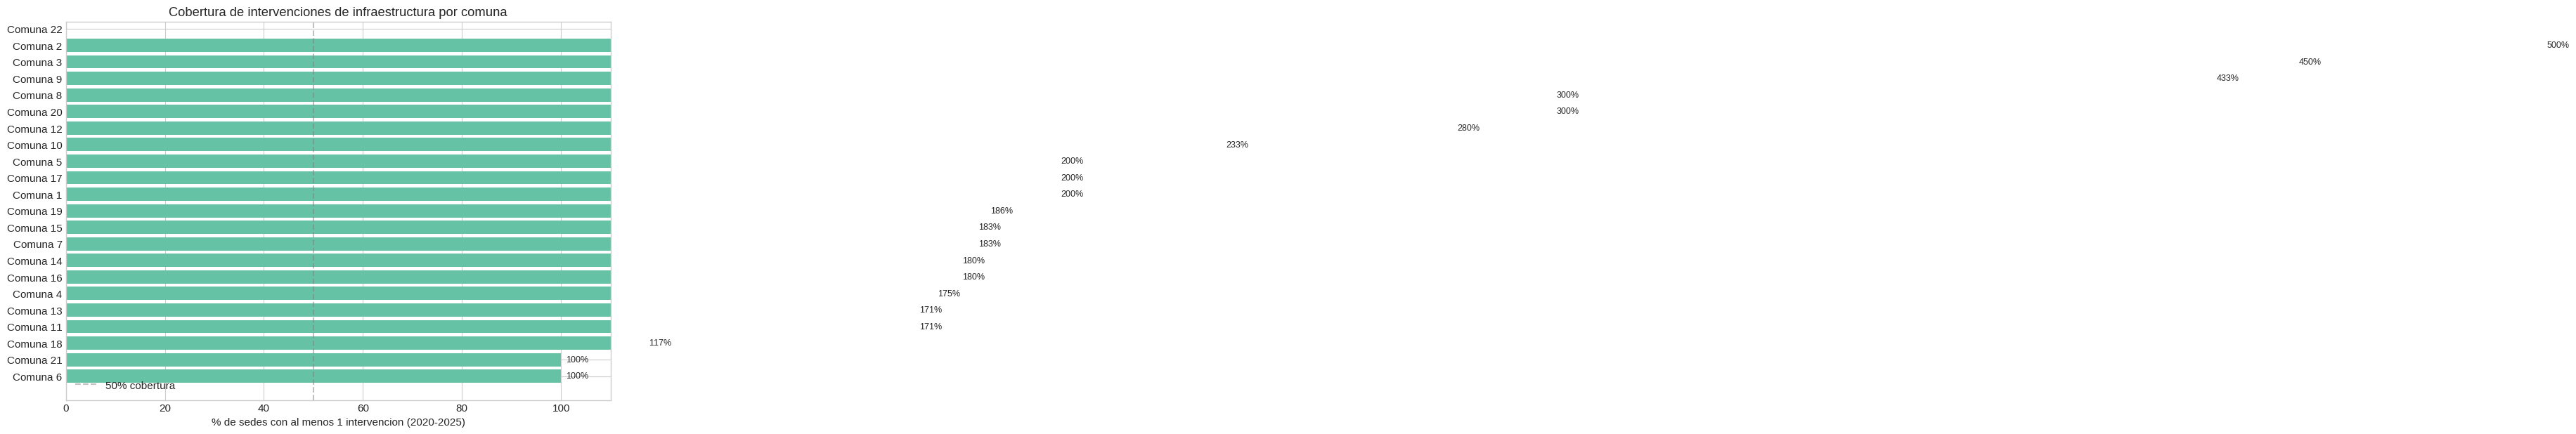

In [159]:
# Grafico: % sedes intervenidas por comuna
df_plot = df_comp.sort_values('pct_sedes_intervenidas', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e78ac3' if v < 30 else '#fc8d62' if v < 60 else '#66c2a5'
          for v in df_plot['pct_sedes_intervenidas']]
bars = ax.barh(df_plot['comuna'], df_plot['pct_sedes_intervenidas'], color=colors)
ax.axvline(50, color='gray', linestyle='--', alpha=0.5, label='50% cobertura')
ax.set_xlabel('% de sedes con al menos 1 intervencion (2020-2025)')
ax.set_title('Cobertura de intervenciones de infraestructura por comuna')
ax.set_xlim(0, 110)
ax.legend()
for bar in bars:
    w = bar.get_width()
    ax.text(w+1, bar.get_y()+bar.get_height()/2, f'{w:.0f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 12.2 Inversion per capita (por estudiante) vs Score Educacion

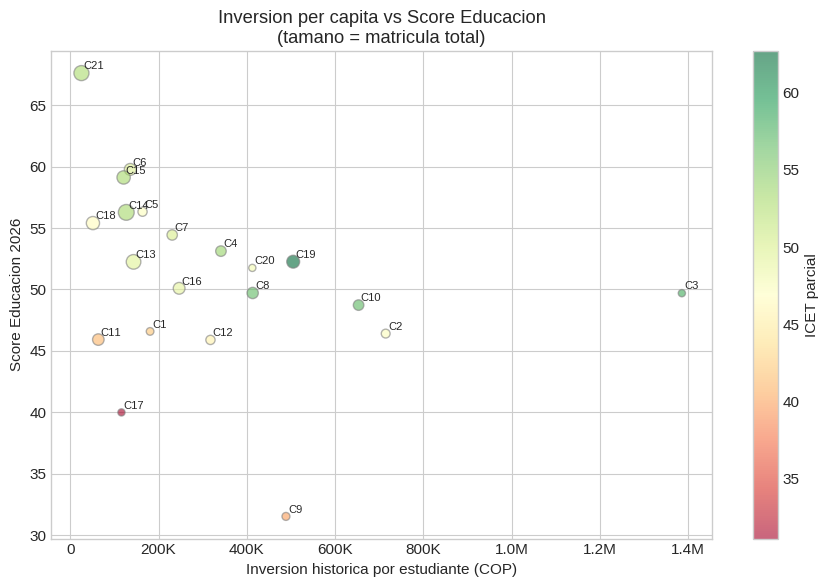

In [160]:
# Scatter: Inversion por estudiante vs Score Educacion
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(df_comp['inversion_por_estudiante'], df_comp['score_educacion'],
               s=df_comp['matricula_total']/200, alpha=0.6,
               c=df_comp['icet_parcial'], cmap='RdYlGn', edgecolors='gray')
for _, row in df_comp.iterrows():
    ax.annotate(f"C{int(row['num_comuna'])}",
                (row['inversion_por_estudiante']+5000, row['score_educacion']+0.3), fontsize=8)
ax.set_xlabel('Inversion historica por estudiante (COP)')
ax.set_ylabel('Score Educacion 2026')
ax.set_title('Inversion per capita vs Score Educacion\n(tamano = matricula total)')
fmt_eje(ax, 'x')
plt.colorbar(sc, ax=ax, label='ICET parcial')
plt.tight_layout()
plt.show()

### 12.3 Obras acumuladas vs Ratio est/equipo actual

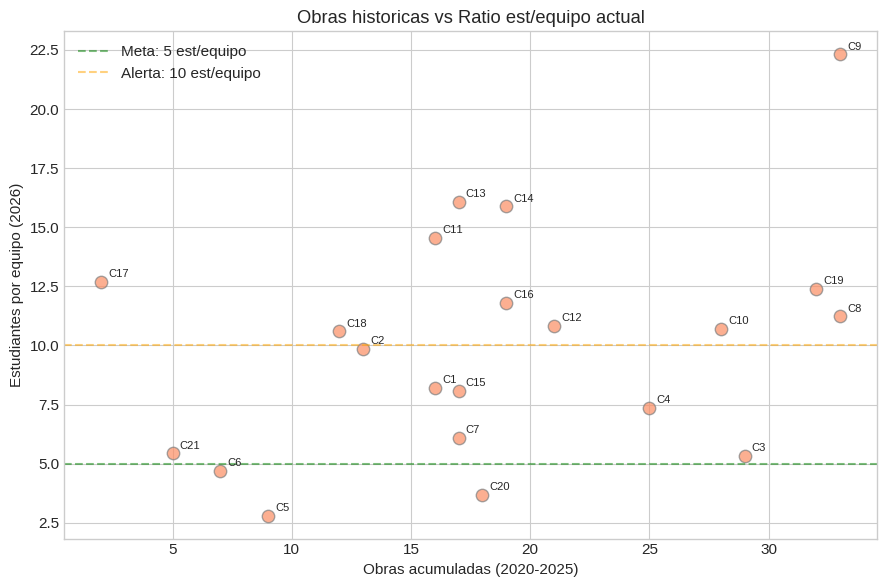

Correlacion obras vs est/equipo: r = 0.366
  -> Mas obras NO se traduce en mejor ratio. Posible explicacion:
     Las obras son de infraestructura fisica, no de dotacion tecnologica.


In [161]:
# Scatter: Obras vs est/equipo (mas obras deberia = mejor dotacion?)
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df_comp['obras_total'], df_comp['est_equipo_prom'],
           s=80, alpha=0.7, color='#fc8d62', edgecolors='gray')
for _, row in df_comp.iterrows():
    ax.annotate(f"C{int(row['num_comuna'])}",
                (row['obras_total']+0.3, row['est_equipo_prom']+0.2), fontsize=8)
ax.axhline(5, color='green', linestyle='--', alpha=0.5, label='Meta: 5 est/equipo')
ax.axhline(10, color='orange', linestyle='--', alpha=0.5, label='Alerta: 10 est/equipo')
ax.set_xlabel('Obras acumuladas (2020-2025)')
ax.set_ylabel('Estudiantes por equipo (2026)')
ax.set_title('Obras historicas vs Ratio est/equipo actual')
ax.legend()
plt.tight_layout()
plt.show()

# Correlacion
r = df_comp[['obras_total', 'est_equipo_prom']].corr().iloc[0,1]
print(f'Correlacion obras vs est/equipo: r = {r:.3f}')
if r > 0:
    print('  -> Mas obras NO se traduce en mejor ratio. Posible explicacion:')
    print('     Las obras son de infraestructura fisica, no de dotacion tecnologica.')
else:
    print('  -> Mas obras SI se asocia con mejor ratio est/equipo.')

### 12.4 Evolucion de obras por ano y comunas prioritarias

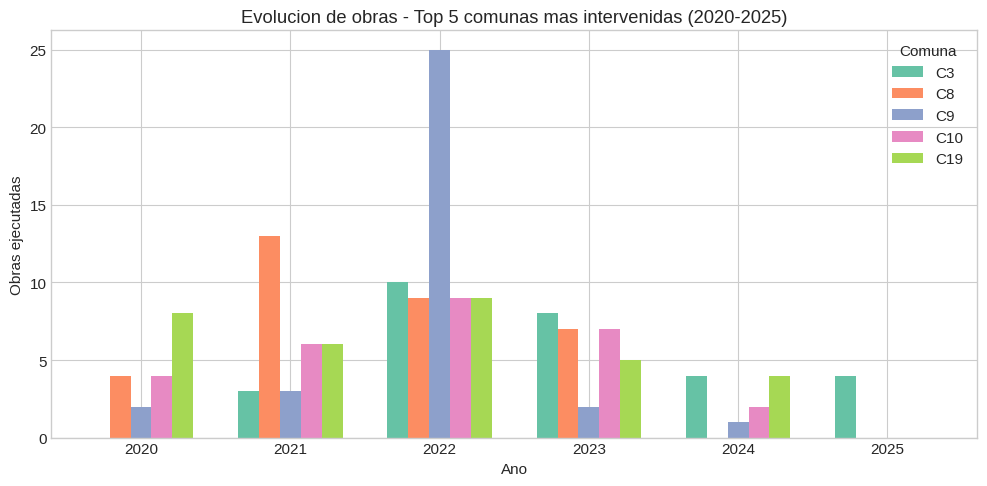

In [162]:
# Evolucion: obras por ano para top 5 comunas con mas intervencion
top5 = df_comp.nlargest(5, 'obras_total')['num_comuna'].values

pivot_top = df_obras_urb[df_obras_urb['Com_num'].isin(top5)].groupby(
    ['Com_num', 'Ano']).size().reset_index(name='obras')
pivot_top = pivot_top.pivot(index='Ano', columns='Com_num', values='obras').fillna(0)
pivot_top.columns = [f'C{int(c)}' for c in pivot_top.columns]

fig, ax = plt.subplots(figsize=(10, 5))
pivot_top.plot(kind='bar', ax=ax, width=0.7)
ax.set_xlabel('Ano')
ax.set_ylabel('Obras ejecutadas')
ax.set_title('Evolucion de obras - Top 5 comunas mas intervenidas (2020-2025)')
ax.legend(title='Comuna')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 12.5 Hallazgos de la comparacion

In [163]:
# Resumen de hallazgos
print('=' * 70)
print('HALLAZGOS: HISTORICO vs 2026')
print('=' * 70)

# Comunas con mas inversion pero peor score
alta_inv = df_comp.nlargest(5, 'inversion_M')[['comuna', 'inversion_M', 'score_educacion', 'est_equipo_prom']]
print('\n1. Top 5 comunas con mayor inversion historica:')
print(alta_inv.to_string(index=False))

# Comunas con peor ratio est/equipo
peor_ratio = df_comp.nlargest(5, 'est_equipo_prom')[['comuna', 'est_equipo_prom', 'obras_total', 'score_educacion']]
print('\n2. Top 5 comunas con peor ratio est/equipo (necesitan dotacion):')
print(peor_ratio.to_string(index=False))

# Comunas con menor cobertura de intervenciones
baja_cob = df_comp.nsmallest(5, 'pct_sedes_intervenidas')[['comuna', 'pct_sedes_intervenidas', 'sedes_total', 'obras_total']]
print('\n3. Top 5 comunas con menor % de sedes intervenidas (brecha infraestructura):')
print(baja_cob.to_string(index=False))

# Comunas prioritarias (bajo score + baja inversion)
df_comp['prioridad'] = (100 - df_comp['icet_parcial']) + (100 - df_comp['pct_sedes_intervenidas'])
prioritarias = df_comp.nlargest(5, 'prioridad')[['comuna', 'icet_parcial', 'pct_sedes_intervenidas', 'prioridad']]
print('\n4. Comunas prioritarias (bajo ICET + baja cobertura de obras):')
print(prioritarias.to_string(index=False))

print('\n--- Conclusion ---')
print('La inversion historica en infraestructura fisica no se traduce directamente')
print('en mejores indicadores de dotacion tecnologica (est/equipo).')
print('Las comunas con mayor necesidad de intervencion integral son aquellas con')
print('bajo ICET Y baja cobertura de obras historicas.')

HALLAZGOS: HISTORICO vs 2026

1. Top 5 comunas con mayor inversion historica:
   comuna  inversion_M  score_educacion  est_equipo_prom
Comuna 19     8,725.84            52.26            12.38
 Comuna 3     7,532.88            49.70             5.33
Comuna 10     7,526.78            48.73            10.70
 Comuna 2     5,790.54            46.41             9.86
 Comuna 8     5,457.90            49.71            11.23

2. Top 5 comunas con peor ratio est/equipo (necesitan dotacion):
   comuna  est_equipo_prom  obras_total  score_educacion
 Comuna 9            22.31        33.00            31.53
Comuna 13            16.07        17.00            52.25
Comuna 14            15.89        19.00            56.28
Comuna 11            14.55        16.00            45.92
Comuna 17            12.70         2.00            39.99

3. Top 5 comunas con menor % de sedes intervenidas (brecha infraestructura):
   comuna  pct_sedes_intervenidas  sedes_total  obras_total
 Comuna 6                  100.00 